Credit Card Segmentation: Exploratory Data Analysis & Hyperparameter Tuning

Goal: Understand the distribution of customer credit card behaviors, handle missing data, and mathematically determine the optimal number of customer segments using K-Means clustering.

Key Steps:
1. Initial Data Inspection & Imputation
2. Distribution & Correlation Analysis
3. Feature Scaling
4. Hyperparameter Tuning (Elbow Method & Silhouette Score)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set visualization styles for professional-looking plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load the dataset
df = pd.read_csv('C:\\customer_segmentation\\Credit-Card-Customer-Segmentation\\data\\CC GENERAL.csv')

# Drop CUST_ID (it's a primary key, not a behavioral feature)
df = df.drop('CUST_ID', axis=1)

# Display initial info
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Check for missing values before
print("Missing values before imputation:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Impute using explicit assignment (Modern Pandas standard)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Check for missing values after
print("\nMissing values after imputation:", df.isnull().sum().sum())

Missing values before imputation:
 CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing values after imputation: 0


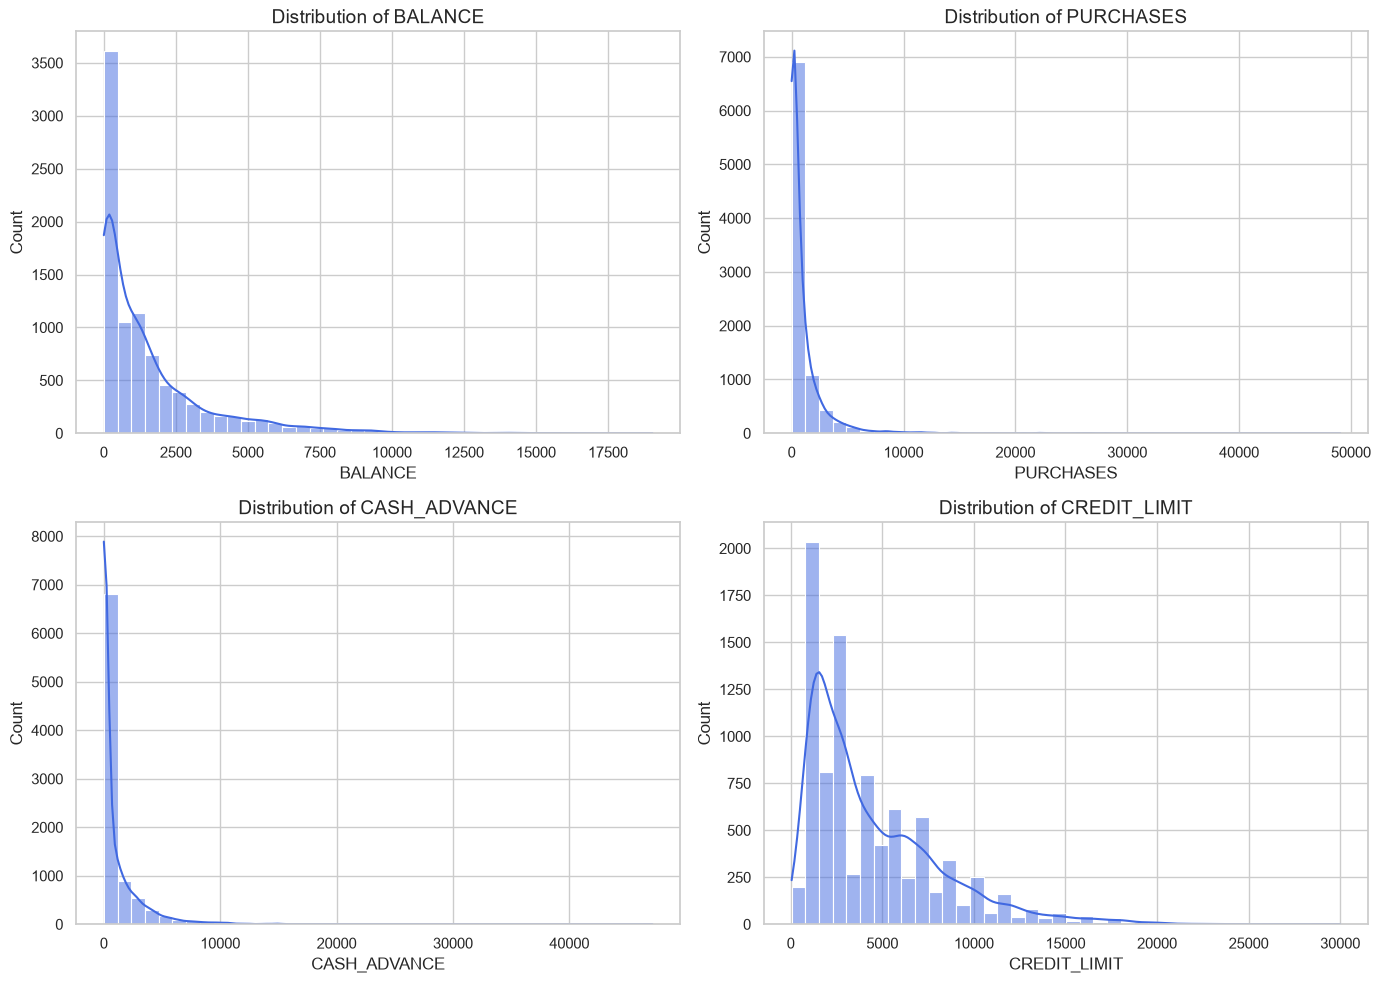

In [5]:
# Plot histograms for a few key financial behaviors
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.histplot(df[feature], bins=40, kde=True, ax=axes[row, col], color='royalblue')
    axes[row, col].set_title(f'Distribution of {feature}', fontsize=14)

plt.tight_layout()
plt.show()

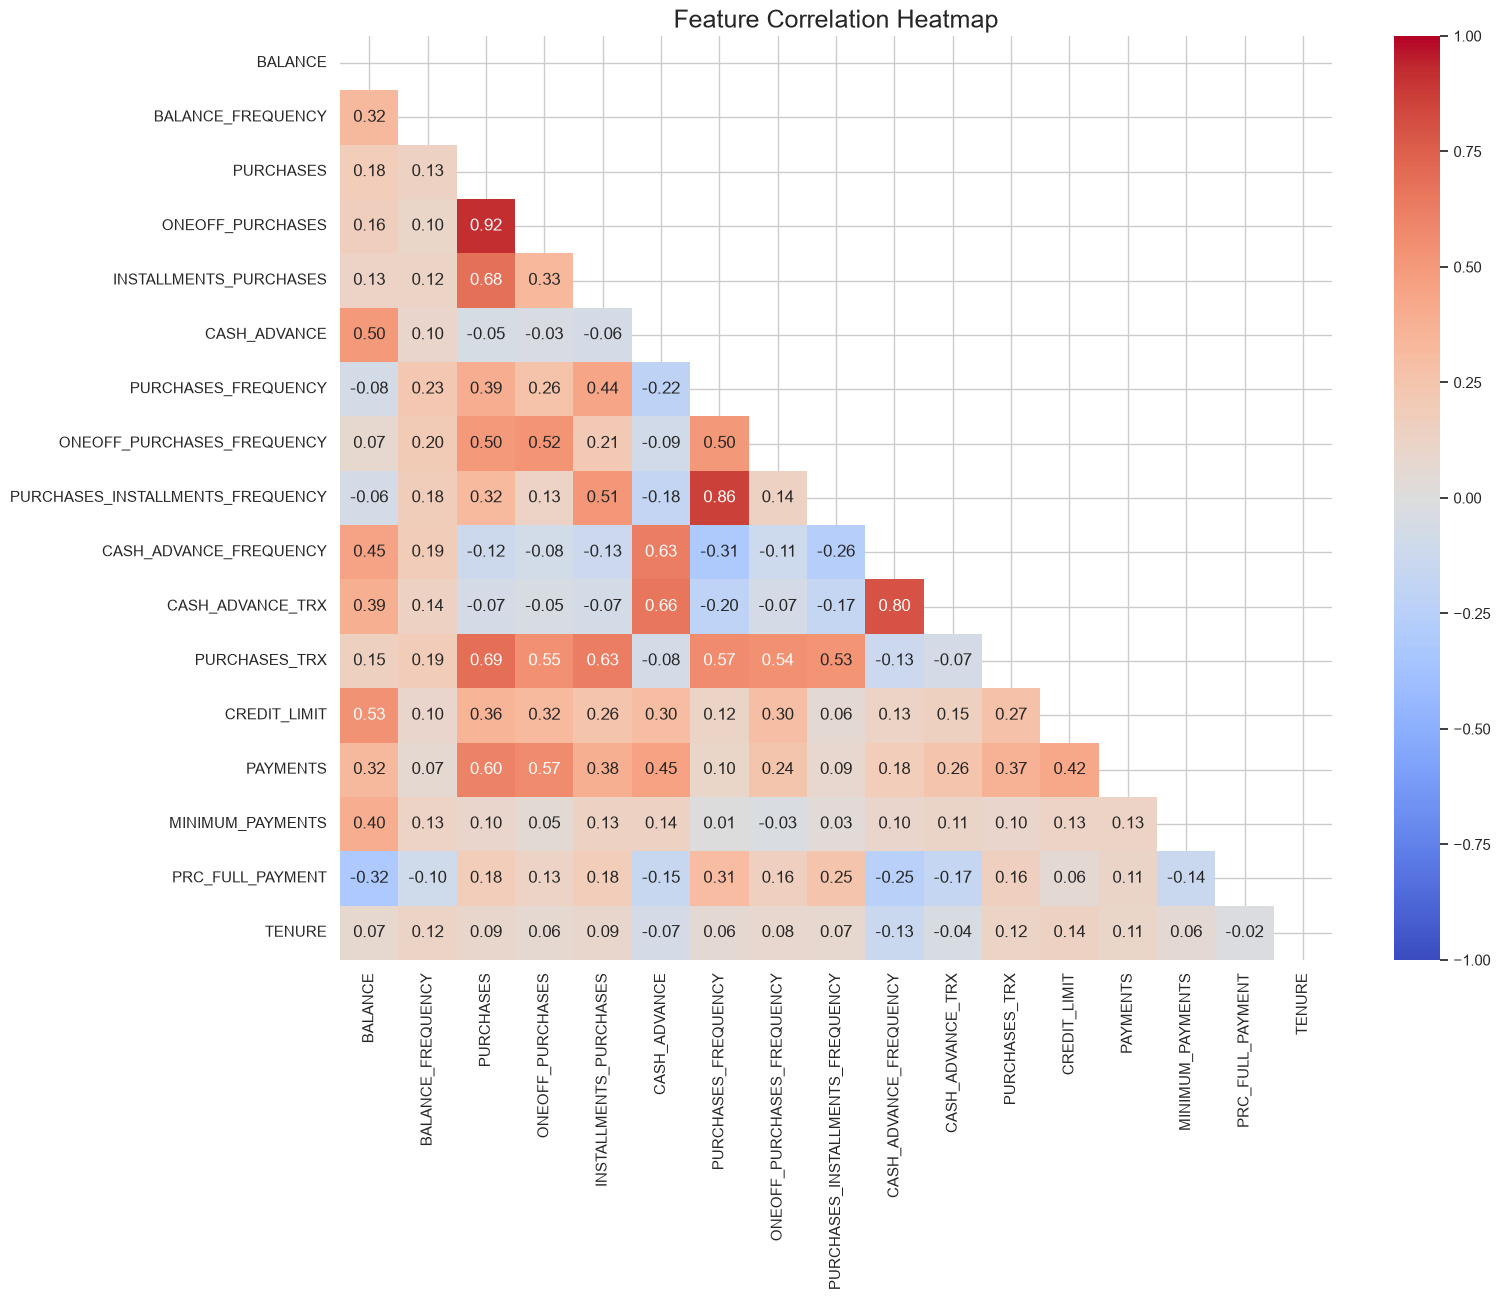

In [6]:
# Create a correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()

# Use a mask to only show the bottom triangle (looks much cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()

In [7]:
# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

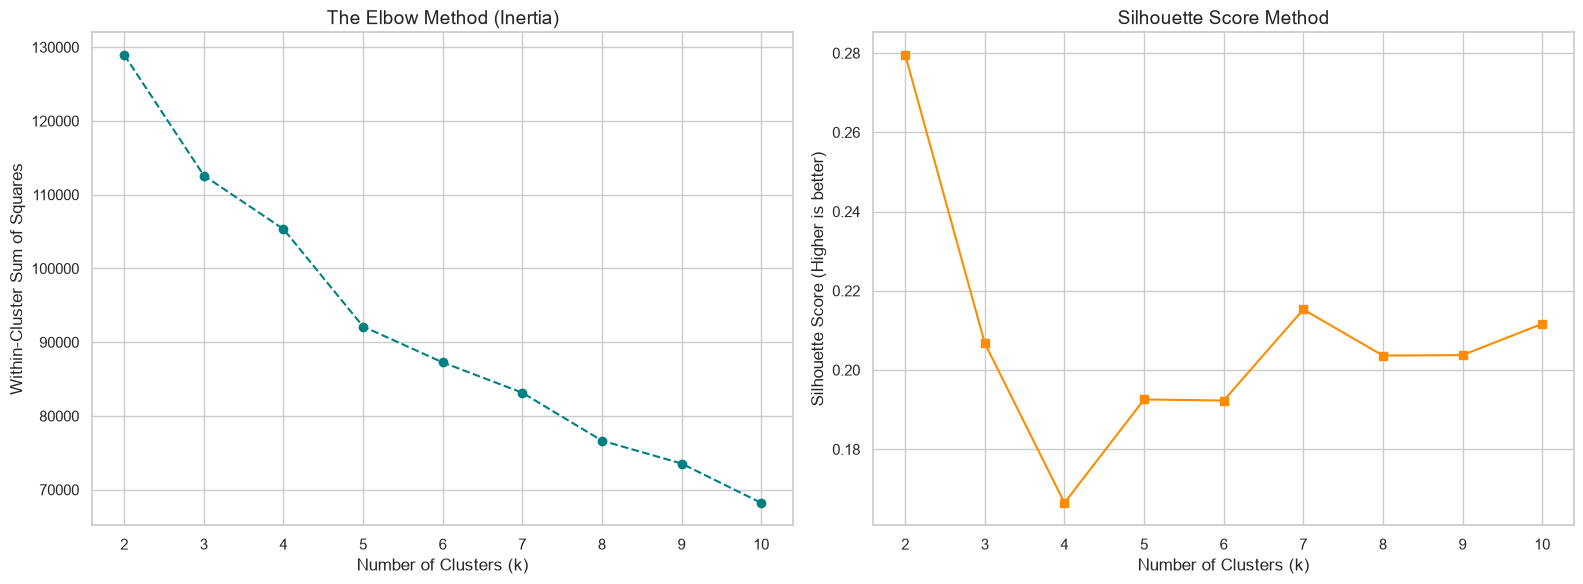

In [8]:
# We will test k values from 2 to 10
k_range = range(2, 11)
inertia = []
silhouette_scores = []

# This loop might take a minute to run depending on your machine
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    
    inertia.append(kmeans.inertia_)
    # Calculate silhouette score
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting both metrics side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method (Inertia)
axes[0].plot(k_range, inertia, marker='o', linestyle='--', color='teal')
axes[0].set_title('The Elbow Method (Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].set_xticks(k_range)

# Plot 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='darkorange')
axes[1].set_title('Silhouette Score Method', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (Higher is better)')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()